In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [48]:
df = pd.read_csv("ZARA_sales_EDA.csv", sep = ";")
df.info()
df.isnull().any()
df.sample(3)


<class 'pandas.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20252 non-null  int64  
 1   Product Position  20252 non-null  str    
 2   Promotion         20252 non-null  str    
 3   Product Category  20252 non-null  str    
 4   Seasonal          20252 non-null  str    
 5   Sales Volume      20252 non-null  int64  
 6   brand             20252 non-null  str    
 7   url               20252 non-null  str    
 8   name              20251 non-null  str    
 9   description       20250 non-null  str    
 10  price             20252 non-null  float64
 11  currency          20252 non-null  str    
 12  terms             20252 non-null  str    
 13  section           20252 non-null  str    
 14  season            20252 non-null  str    
 15  material          20252 non-null  str    
 16  origin            20252 non-null  str    
dtypes: f

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
14924,214304,Aisle,No,clothing,Yes,1041,Zara,https://www.zara.com/us/en/baggy-fit-jeans-p06...,LINEN ZIPPERED WOOL BLEND OVERSHIRT TAUPE,Sneakers. Upper in a combination of pieces and...,27.99,USD,jackets,MAN,Summer,Linen Blend,Morocco
16817,216197,Aisle,Yes,clothing,Yes,1179,Zara,https://www.zara.com/us/en/plaid-overshirt-p04...,ACID WASH DENIM JACKET SAND,Round neck long sleeve sweater. Openwork detai...,88.95,USD,shoes,WOMAN,Autumn,Wool,Spain
14039,213419,Front of Store,Yes,clothing,Yes,1208,Zara,https://www.zara.com/us/en/knit-sweater-with-p...,TEXTURED EMBROIDERED FOREST JACKET ECRU,Sneakers. Made of leather. Upper in a combinat...,57.99,USD,shoes,WOMAN,Autumn,Polyester,Morocco


As we can see from the info function call, that only the namesa columns and description have any missing data, and the number of missing items would not really affect our analysis till now.

so we will drop all nan data as they wont really affect us.

lets first explore what does season and origin mean

In [49]:
df.dropna(inplace = True)

In [50]:
df['origin']


0         Brazil
1         Turkey
2        Morocco
3          China
4          China
          ...   
20247      India
20248      China
20249      China
20250      Spain
20251     Turkey
Name: origin, Length: 20250, dtype: str

In [51]:
df['season']

0        Winter
1        Autumn
2        Autumn
3        Spring
4        Winter
          ...  
20247    Summer
20248    Spring
20249    Spring
20250    Winter
20251    Summer
Name: season, Length: 20250, dtype: str

season indicates when an item is suitable for wear while origin indicates an items place of making.

Lets check for missing values or inconsistencies

In [52]:
df[df['section'].str.contains("WOMAN")]

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China
5,117590,End-cap,Yes,clothing,Yes,1282,Zara,https://www.zara.com/us/en/contrasting-collar-...,CONTRASTING COLLAR JACKET,Relaxed fit jacket. Contrasting lapel collar a...,25.95,USD,jackets,WOMAN,Autumn,Cotton,Turkey
7,182157,Aisle,Yes,clothing,Yes,1711,Zara,https://www.zara.com/us/en/suit-jacket-in-100-...,SUIT JACKET IN 100% LINEN,Straight fit blazer made of linen. Notched lap...,24.00,USD,jackets,WOMAN,Summer,Cotton,Portugal
8,141861,Aisle,No,clothing,Yes,857,Zara,https://www.zara.com/us/en/100-wool-suit-jacke...,100% WOOL SUIT JACKET,Jacket made of Italian wool. Pointed lapel col...,32.95,USD,jackets,WOMAN,Winter,Wool,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20246,219626,End-cap,No,clothing,No,1012,Zara,https://www.zara.com/us/en/washed-effect-bombe...,TEXTURED SUEDE FISHERMAN SANDALS BROWN,Sneakers. Upper in a combination of pieces and...,48.99,USD,jackets,WOMAN,Summer,Cotton,China
20247,219627,Front of Store,Yes,clothing,No,1754,Zara,https://www.zara.com/us/en/suit-jacket-in-100-...,CROPPED WASHED T-SHIRT CHARCOAL,Running shoes. Upper in a combination of piece...,31.95,USD,jeans,WOMAN,Summer,Linen Blend,India
20248,219628,Aisle,No,clothing,No,872,Zara,https://www.zara.com/us/en/fleece-overshirt-p0...,SATIN WOVEN LEATHER SLIDES STONE,Slim fit shirt. Round neck and short sleeves.,49.99,USD,jackets,WOMAN,Spring,Linen,China
20249,219629,Aisle,Yes,clothing,No,1360,Zara,https://www.zara.com/us/en/faux-suede-patch-ja...,RELAXED CROPPED LEATHER JACKET CHARCOAL,Ankle boots. Made of leather with a suede fini...,20.99,USD,shoes,WOMAN,Spring,Polyester,China


In [53]:
df[df['section'].str.contains("MAN")]

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20247,219627,Front of Store,Yes,clothing,No,1754,Zara,https://www.zara.com/us/en/suit-jacket-in-100-...,CROPPED WASHED T-SHIRT CHARCOAL,Running shoes. Upper in a combination of piece...,31.95,USD,jeans,WOMAN,Summer,Linen Blend,India
20248,219628,Aisle,No,clothing,No,872,Zara,https://www.zara.com/us/en/fleece-overshirt-p0...,SATIN WOVEN LEATHER SLIDES STONE,Slim fit shirt. Round neck and short sleeves.,49.99,USD,jackets,WOMAN,Spring,Linen,China
20249,219629,Aisle,Yes,clothing,No,1360,Zara,https://www.zara.com/us/en/faux-suede-patch-ja...,RELAXED CROPPED LEATHER JACKET CHARCOAL,Ankle boots. Made of leather with a suede fini...,20.99,USD,shoes,WOMAN,Spring,Polyester,China
20250,219630,Aisle,No,clothing,No,892,Zara,https://www.zara.com/us/en/fine-knit-crop-swea...,SLIM BASIC 100% WOOL SWEATER BURGUNDY,RETRO SNEAKERS,64.95,USD,jackets,WOMAN,Winter,Polyester,Spain


In [54]:

df[df['section'].str.contains(r'^(?!MAN$|WOMAN$)(?:m|M|MALE|male|man|F|f|woman|FEMALE)')]

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin


As we can see there exists no items that arent made for 'WOMEN' or 'MEN' in discription and no outliers.

We will also check the curriencies used to be able to do analysis on prices effictively


In [55]:
df['currency'].unique()


<StringArray>
['USD']
Length: 1, dtype: str

We see that all the currency used is in USD, now we will check if all pieces are actually manufactured by ZARA.

In [56]:
df['brand'].unique()

<StringArray>
['Zara']
Length: 1, dtype: str

Now we will explore univariate analysis using a histplot for the price to check where the majority of the prices fall and where the median is.

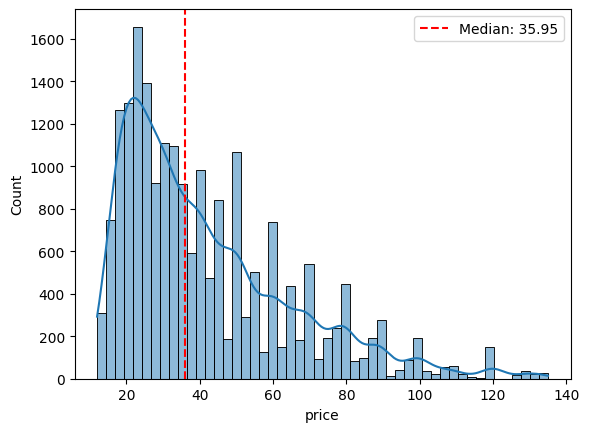

In [57]:

median = df['price'].median()
#print(median)
sns.histplot(df['price'], bins=50,kde = True)
plt.axvline(median, color='red', linestyle='--', label=f'Median: {median:.2f}')
plt.legend()
plt.show()

This piece of code basically shows the data items prices and their median in the same graph, the median is plotted as red ('--') line.


The cost median of all items is about 35.95 dollar, as we can see that the majority of prices fall in the range from 15 dollar up to about 42 dollars, but items 60 and higher and skewing the range with low number of items having such high prices but with a variation of prices big enough to show on the median.

Another univariate to check is which is the single most producing country of zara clothes accoding to the data

<Axes: xlabel='Count', ylabel='origin'>

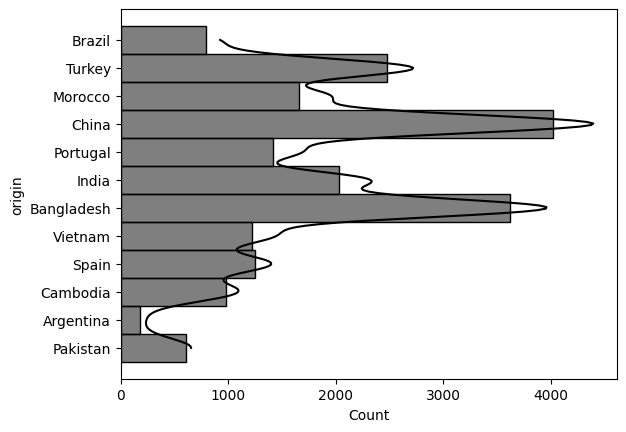

In [58]:
sns.histplot(y = df['origin'], color = 'black', kde = True)

It is apparent that Asian and esp eastern Asian countries are in the lead in terms of manufacturing count, countries like China, Bangladesh and Trukey are the biggest 3, which is logical for their low wage rates.

Lets now explore the relationship between those countries and the prices of the items they produce , using a boxplot

<Axes: xlabel='price', ylabel='origin'>

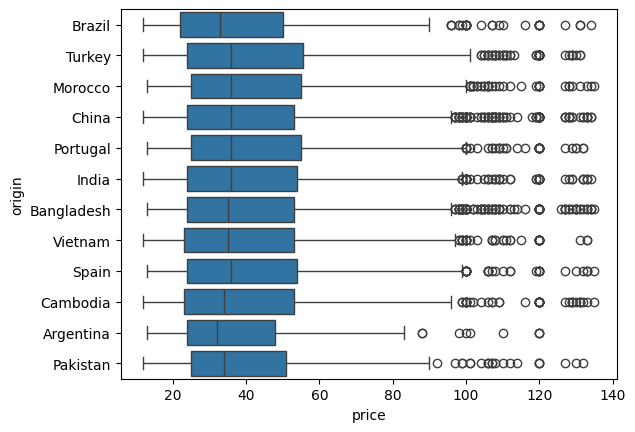

In [61]:
sns.boxplot(data = df, y = 'origin', x = 'price')

All countires have a median price that is around the same to the whole median of 35.

Almost every country has a significant number of expensive items reaching nearly 120-140 dollars.

Countries like Paki and India have slightly lower price ranges compared to Turkey or BR.

Now we explore how seasonal clothes relate to prices.

<Axes: xlabel='season', ylabel='price'>

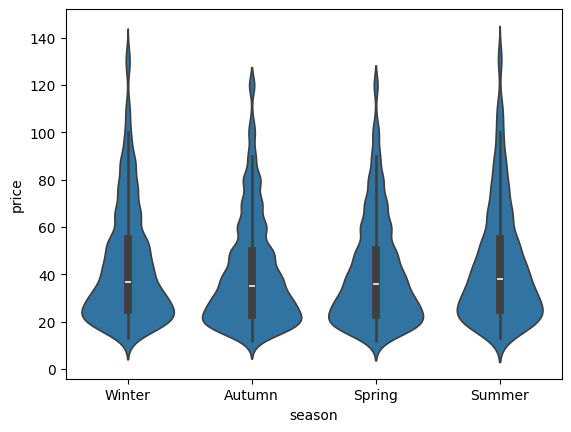

In [72]:
sns.violinplot(df, x='season',y= 'price' )

We see that all seasons share aprox the same mean, while summer and winter most expensive items are slightly more expensive than spring and autmn most expensive ones.


Lets now check which seasons clothes do customers perfer from zara.


<Axes: xlabel='season', ylabel='Sales Volume'>

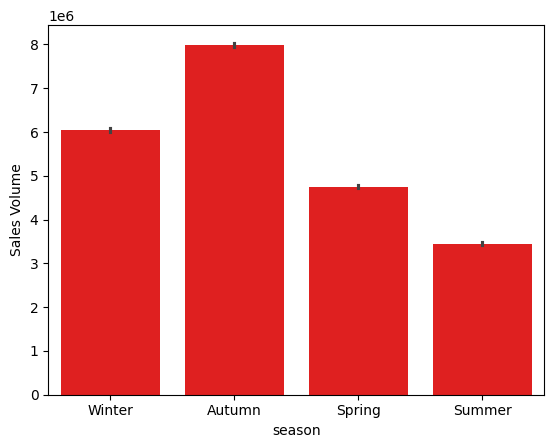

In [77]:
sns.barplot(df,x='season', y = 'Sales Volume', estimator = "sum", color='red')

Surpisingly people perfer ZARA's autmn collection far more than summer's or spring even tho summer is where they usually release their high ticket pieces which tend to be more expensive.